In [ ]:
from google.colab import files
uploaded = files.upload()

Saving crime scene1.jpeg to crime scene1 (1).jpeg
Saving crime scene2.jpeg to crime scene2.jpeg
Saving Crime scene3.jpeg to Crime scene3.jpeg
Saving crime scene4.jpeg to crime scene4.jpeg
Saving Crime scene5.jpeg to Crime scene5.jpeg
Saving Crime scene6.jpeg to Crime scene6.jpeg
Saving Crimescene3.jpeg to Crimescene3.jpeg


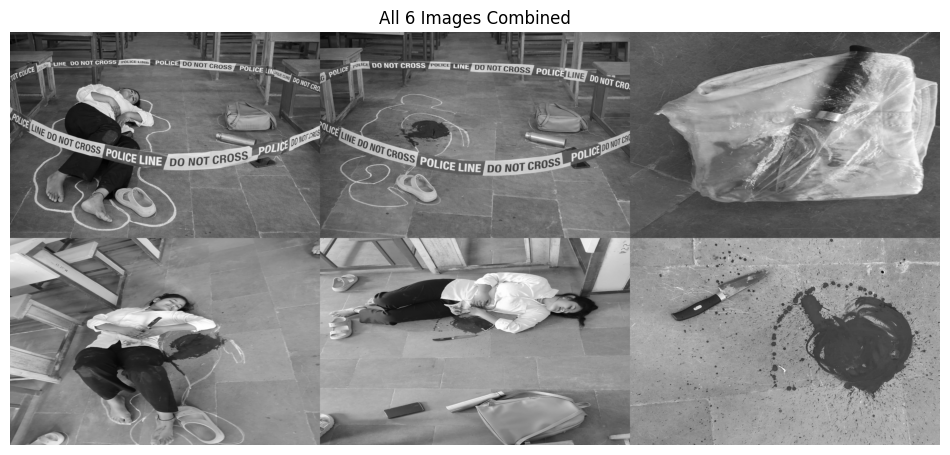

In [ ]:
import numpy as np

# List to store grayscale images
gray_images = []

# Load all grayscale images
for filename in uploaded.keys():
    img = cv2.imread(filename)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray_images.append(gray)

# Resize images to same size (for uniform grid)
height, width = gray_images[0].shape
resized_images = [cv2.resize(img, (width, height)) for img in gray_images]

# Combine images into 2x3 grid (2 rows, 3 columns)
row1 = np.hstack(resized_images[0:3])
row2 = np.hstack(resized_images[3:6])
grid = np.vstack([row1, row2])

# Display the combined grid
plt.figure(figsize=(12,8))
plt.title("All 6 Images Combined")
plt.imshow(grid, cmap='gray')
plt.axis('off')
plt.show()

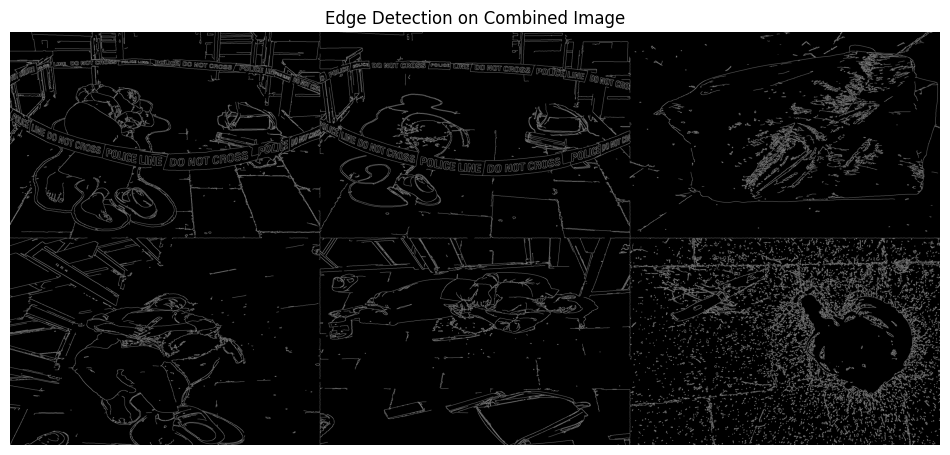

In [ ]:
# Apply Canny Edge Detection on combined image
edges = cv2.Canny(grid, threshold1=50, threshold2=150)

# Display edges
plt.figure(figsize=(12,8))
plt.title("Edge Detection on Combined Image")
plt.imshow(edges, cmap='gray')
plt.axis('off')
plt.show()

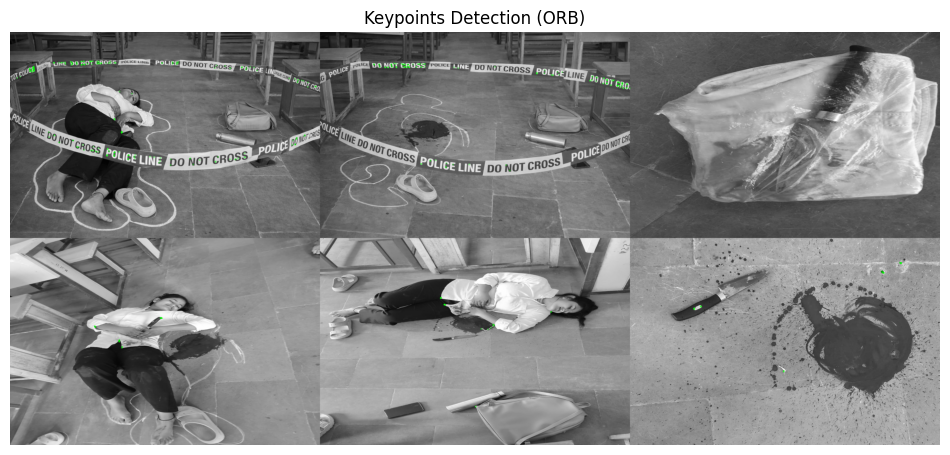

Number of keypoints detected: 500


In [ ]:
# Initialize ORB detector
orb = cv2.ORB_create()

# Detect keypoints and descriptors
keypoints, descriptors = orb.detectAndCompute(grid, None)

# Draw keypoints on the image
img_keypoints = cv2.drawKeypoints(grid, keypoints, None, color=(0,255,0), flags=0)

# Display keypoints
plt.figure(figsize=(12,8))
plt.title("Keypoints Detection (ORB)")
plt.imshow(img_keypoints, cmap='gray')
plt.axis('off')
plt.show()

print(f"Number of keypoints detected: {len(keypoints)}")

In [ ]:
cv2.imwrite("edges.png", edges)
cv2.imwrite("keypoints.png", img_keypoints)
print("Edge and Keypoints images saved successfully!")

Edge and Keypoints images saved successfully!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

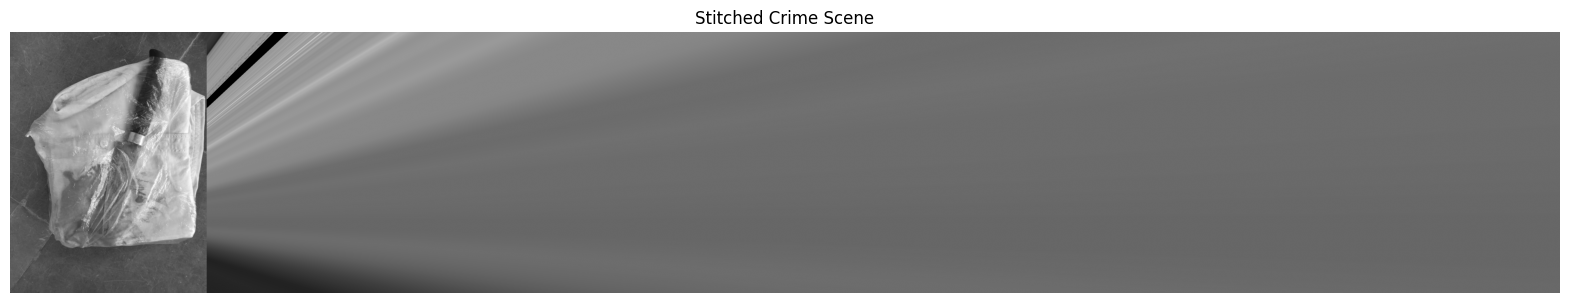

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Function to stitch two images
def stitch_images(img1, img2):
    # Initialize ORB detector
    orb = cv2.ORB_create(5000)

    # Find keypoints and descriptors
    kp1, des1 = orb.detectAndCompute(img1, None)
    kp2, des2 = orb.detectAndCompute(img2, None)

    # Match features using BFMatcher
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(des1, des2)

    # Sort matches by distance
    matches = sorted(matches, key=lambda x: x.distance)

    # Need at least 10 matches to compute homography
    if len(matches) > 10:
        src_pts = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1,1,2)
        dst_pts = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1,1,2)

        # Compute homography
        M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

        # Warp img1 to img2's perspective
        h2, w2 = img2.shape
        warped_img1 = cv2.warpPerspective(img1, M, (w2 + img1.shape[1], h2))

        # Place img2 on the warped canvas
        warped_img1[0:h2, 0:w2] = img2
        return warped_img1
    else:
        print("Not enough matches found!")
        return None

# Convert all uploaded images to grayscale
gray_images = []
for filename in uploaded.keys():
    img = cv2.imread(filename)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray_images.append(gray)

# Stitch images one by one
stitched = gray_images[0]
for i in range(1, len(gray_images)):
    stitched = stitch_images(stitched, gray_images[i])
    if stitched is None:
        print(f"Could not stitch image {i+1}")
        stitched = gray_images[i]  # fallback to next image

# Display final stitched image
plt.figure(figsize=(20,10))
plt.title("Stitched Crime Scene")
plt.imshow(stitched, cmap='gray')
plt.axis('off')
plt.show()

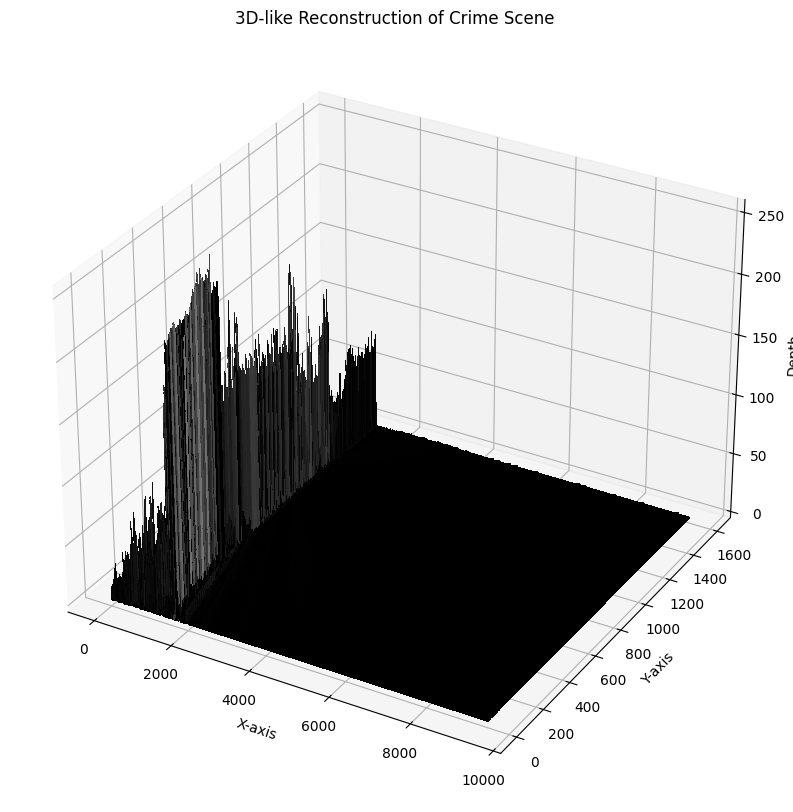

In [ ]:
import cv2
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

# Load stitched image (grayscale)
stitched_gray = stitched  # already from previous step

# Apply Sobel filter to get gradient (simulate depth changes)
grad_x = cv2.Sobel(stitched_gray, cv2.CV_64F, 1, 0, ksize=5)
grad_y = cv2.Sobel(stitched_gray, cv2.CV_64F, 0, 1, ksize=5)
depth_map = np.sqrt(grad_x**2 + grad_y**2)

# Normalize depth map to 0-255
depth_map = cv2.normalize(depth_map, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# Create meshgrid for X, Y coordinates
h, w = depth_map.shape
X, Y = np.meshgrid(np.arange(0, w), np.arange(0, h))
Z = depth_map  # Z-axis = depth

# Plot 3D surface
fig = plt.figure(figsize=(15,10))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, rstride=5, cstride=5, facecolors=plt.cm.gray(Z/255), linewidth=0, antialiased=False)
ax.set_title("3D-like Reconstruction of Crime Scene")
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Depth")
plt.show()

In [ ]:
blurred = cv2.GaussianBlur(stitched_gray, (5,5), 0)
grad_x = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=5)
grad_y = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=5)

In [ ]:
# Export point cloud
points = np.column_stack((X.flatten(), Y.flatten(), Z.flatten()))
np.savetxt("crime_scene_pointcloud.xyz", points, fmt='%d')
print("Point cloud saved!")

Point cloud saved!
